In [1]:
# Rainfall Pattern Prediction - Notebook Script
# Paste into a Jupyter cell and run. Adjust file_path if needed.

# -------- 1. Imports --------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import timedelta

# Models & utilities
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import joblib

import warnings
warnings.filterwarnings("ignore")

# Time series model
import statsmodels.api as sm

# -------- 2. Load dataset --------
# file_path = "/mnt/data/indian_20cities_weather_2023_2024 (1).csv"  # change if needed
df = pd.read_csv("indian_20cities_weather_2023_2024 (1).csv")
print("Raw shape:", df.shape)
display(df.head())

Raw shape: (14620, 10)


,Date,City,State,Rainfall_mm,Temperature_C,Humidity_%,WindSpeed_kmh,AirPressure_hPa,Weather,HeatIndex_C
0,2023-01-01,Chennai,Tamil Nadu,1.8,31.6,85.8,12.3,1005.3,Cloudy,33.3
1,2023-01-02,Chennai,Tamil Nadu,7.4,31.2,50.9,4.8,1004.4,Cloudy,32.2
2,2023-01-03,Chennai,Tamil Nadu,0.0,27.9,62.6,7.9,988.6,Sunny,29.2
3,2023-01-04,Chennai,Tamil Nadu,22.9,32.0,58.5,11.1,1004.0,Rainy,33.2
4,2023-01-05,Chennai,Tamil Nadu,0.0,28.5,59.8,9.5,1004.7,Sunny,29.7


In [3]:
# -------- 3. Basic preprocessing --------
# Convert Date to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# Ensure numeric columns are numeric
num_cols = ['Rainfall_mm', 'Temperature_C', 'Humidity_%', 'WindSpeed_kmh', 'AirPressure_hPa', 'HeatIndex_C']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print("\nColumns & dtypes:")
print(df.dtypes)


Columns & dtypes:
Date               datetime64[ns]
City                       object
State                      object
Rainfall_mm               float64
Temperature_C             float64
Humidity_%                float64
WindSpeed_kmh             float64
AirPressure_hPa           float64
Weather                    object
HeatIndex_C               float64
dtype: object


In [4]:
# -------- 4. Quick checks --------
# Check missing values
print("\nMissing values per column:")
print(df.isna().sum())

# If missing values exist, simple filling strategy (can improve later)
df[num_cols] = df[num_cols].fillna(method='ffill').fillna(method='bfill')


Missing values per column:
Date               0
City               0
State              0
Rainfall_mm        0
Temperature_C      0
Humidity_%         0
WindSpeed_kmh      0
AirPressure_hPa    0
Weather            0
HeatIndex_C        0
dtype: int64


In [12]:
# -------- 5. City list & example city selection --------
cities = df['City'].unique().tolist()
print("\nCities in dataset:", cities)
# Choose a city to demo (you can loop over cities later)
demo_city = cities[6]
print("Demo city:", demo_city)





Cities in dataset: ['Ahmedabad', 'Bengaluru', 'Bhopal', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Hyderabad', 'Indore', 'Jaipur', 'Kanpur', 'Kolkata', 'Lucknow', 'Mumbai', 'Nagpur', 'Patna', 'Pune', 'Thiruvananthapuram', 'Vadodara', 'Visakhapatnam']
Demo city: Delhi


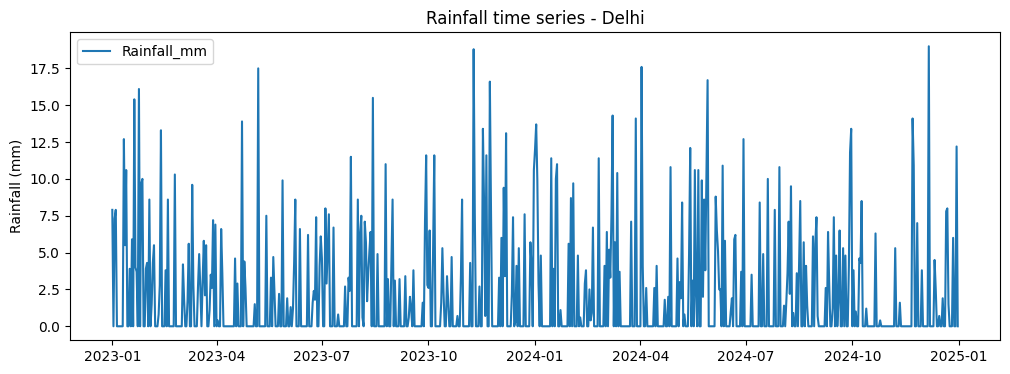

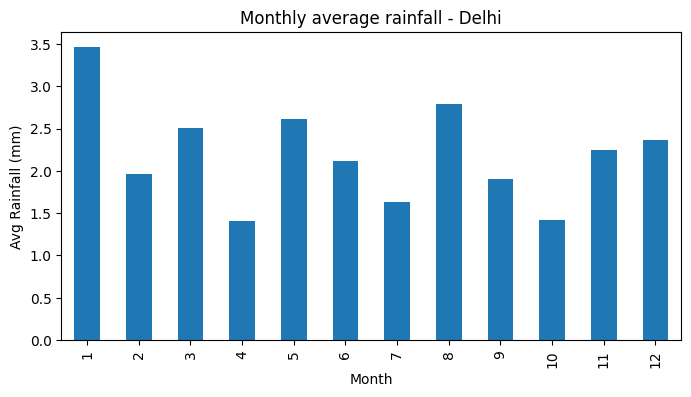

In [9]:
# Function to prepare a single-city time-series DataFrame
def prepare_city_df(city_df):
    """
    Accepts city-specific raw df with Date column and numeric Rainfall_mm.
    Returns a daily-indexed dataframe with missing dates filled (0 rainfall).
    """
    city_df = city_df.set_index('Date').sort_index()
    # Reindex to continuous dates
    full_idx = pd.date_range(city_df.index.min(), city_df.index.max(), freq='D')
    city_df = city_df.reindex(full_idx)
    city_df.index.name = 'Date'
    # Forward/backfill City/State/Weather if needed
    city_df['City'] = city_df['City'].fillna(method='ffill').fillna(method='bfill')
    city_df['State'] = city_df['State'].fillna(method='ffill').fillna(method='bfill')
    # Fill numeric features: rainfall missing -> 0 (no rain), others forward-fill
    city_df['Rainfall_mm'] = city_df['Rainfall_mm'].fillna(0.0)
    for c in ['Temperature_C','Humidity_%','WindSpeed_kmh','AirPressure_hPa','HeatIndex_C']:
        if c in city_df.columns:
            city_df[c] = city_df[c].fillna(method='ffill').fillna(method='bfill')
    return city_df
    
# -------- 6. Exploratory plots (demo city) --------   (line chart)
city_df = df[df['City'] == demo_city].copy()
city_df = prepare_city_df(city_df)
plt.figure(figsize=(12,4))
plt.plot(city_df.index, city_df['Rainfall_mm'], label='Rainfall_mm')
plt.title(f'Rainfall time series - {demo_city}')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

# Monthly average          (BAR chart)
city_df['month'] = city_df.index.month
monthly = city_df.groupby('month')['Rainfall_mm'].mean()
plt.figure(figsize=(8,4))
monthly.plot(kind='bar')
plt.title(f'Monthly average rainfall - {demo_city}')
plt.xlabel('Month')
plt.ylabel('Avg Rainfall (mm)')
plt.show()

In [13]:
# -------- 7. Feature engineering for ML (lag features) --------
def make_lag_features(df_ts, lags=[1,2,3,7,14]):
    df = df_ts.copy()
    for lag in lags:
        df[f'rain_lag_{lag}'] = df['Rainfall_mm'].shift(lag)
    # Date features
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['weekday'] = df.index.weekday
    # Fill remaining NAs after lagging
    df = df.dropna().copy()
    return df

ml_df = make_lag_features(city_df)
display(ml_df.tail())

,City,State,Rainfall_mm,Temperature_C,Humidity_%,WindSpeed_kmh,AirPressure_hPa,Weather,HeatIndex_C,month,rain_lag_1,rain_lag_2,rain_lag_3,rain_lag_7,rain_lag_14,dayofyear,weekday
Date,,,,,,,,,,,,,,,,,
2024-12-27,Delhi,Delhi,6.0,37.9,75.1,10.2,1013.4,Cloudy,39.4,12,0.0,0.0,0.0,0.0,0.0,362,4
2024-12-28,Delhi,Delhi,0.0,25.8,81.8,12.6,1009.9,Sunny,27.4,12,6.0,0.0,0.0,7.8,0.0,363,5
2024-12-29,Delhi,Delhi,0.0,25.7,62.3,8.4,992.1,Sunny,26.9,12,0.0,6.0,0.0,8.0,0.7,364,6
2024-12-30,Delhi,Delhi,12.2,33.1,94.5,13.1,1019.5,Cloudy,35.0,12,0.0,0.0,6.0,1.5,0.0,365,0
2024-12-31,Delhi,Delhi,0.0,31.8,101.0,10.1,1011.4,Sunny,33.8,12,12.2,0.0,0.0,0.0,0.0,366,1


In [14]:
# -------- 8. Split train/test (time-series aware) --------
# We'll reserve last 90 days as test for demonstration (for real project adapt as needed)
test_days = 90
train = ml_df.iloc[:-test_days]
test = ml_df.iloc[-test_days:]

X_cols = [c for c in train.columns if c not in ['City','State','Weather','Rainfall_mm']]
y_col = 'Rainfall_mm'

X_train = train[X_cols]
y_train = train[y_col]
X_test = test[X_cols]
y_test = test[y_col]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (627, 13) (627,)
Test shape: (90, 13) (90,)


In [15]:
# -------- 9. Random Forest model (regression) --------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import os

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
pred_rf = rf.predict(X_test)

# Metrics (manual RMSE calculation for older sklearn versions)
mae_rf = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = mse_rf ** 0.5

print(f"RandomForest - MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}")

# Save RF model
os.makedirs('models', exist_ok=True)
joblib.dump(rf, f'models/rf_rain_{demo_city.replace(' ','_')}.joblib')


RandomForest - MAE: 3.114, RMSE: 3.797


['models/rf_rain_Delhi.joblib']

In [16]:
# -------- 10. Simple ARIMA/SARIMAX forecast (univariate) --------
import statsmodels.api as sm

train_ts = city_df['Rainfall_mm'][:-test_days]
test_ts = city_df['Rainfall_mm'][-test_days:]

# Fit SARIMAX
sarimax_order = (1,1,1)
seasonal_order = (1,0,1,12)  # seasonal yearly
model = sm.tsa.SARIMAX(train_ts, order=sarimax_order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)

# Forecast
forecast_sarimax = res.get_forecast(steps=test_days)
pred_sarimax = forecast_sarimax.predicted_mean

# Metrics
mae_sar = mean_absolute_error(test_ts, pred_sarimax)
mse_sar = mean_squared_error(test_ts, pred_sarimax)
rmse_sar = mse_sar ** 0.5

print(f"SARIMAX - MAE: {mae_sar:.3f}, RMSE: {rmse_sar:.3f}")


SARIMAX - MAE: 2.765, RMSE: 3.541


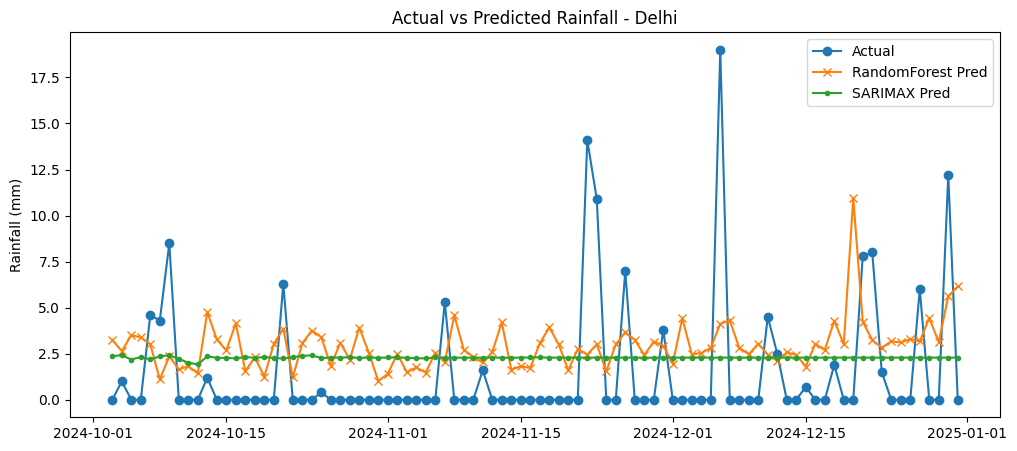

In [17]:
# -------- 11. Plot predictions vs actual --------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_ts.index, test_ts.values, label='Actual', marker='o')
plt.plot(test_ts.index, pred_rf, label='RandomForest Pred', marker='x')

# Plot SARIMAX only if available
try:
    plt.plot(test_ts.index, pred_sarimax, label='SARIMAX Pred', marker='.')
except:
    pass

plt.title(f"Actual vs Predicted Rainfall - {demo_city}")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()


In [18]:
# -------- 12. 7-day RandomForest forecast (fixed) --------
from datetime import timedelta

def forecast_next_n_rf(last_known_df, rf_model, n=7):
    df_roll = last_known_df.copy()
    preds = []
    for i in range(n):
        X_row = df_roll.iloc[[-1]][X_cols]
        yhat = rf_model.predict(X_row)[0]
        preds.append(yhat)

        # create next row
        next_index = df_roll.index[-1] + timedelta(days=1)
        new_row = df_roll.iloc[[-1]].copy()
        new_row.index = [next_index]
        new_row['Rainfall_mm'] = yhat

        # FIX: replace append with concat
        df_roll = pd.concat([df_roll, new_row])

    return pd.Series(preds, index=[df_roll.index[-n + i] for i in range(n)])

# Run forecast
rf_7d = forecast_next_n_rf(ml_df, rf, n=7)
print("\n7-day RandomForest forecast:")
print(rf_7d)




7-day RandomForest forecast:
2025-01-01    6.1585
2025-01-02    6.1585
2025-01-03    6.1585
2025-01-04    6.1585
2025-01-05    6.1585
2025-01-06    6.1585
2025-01-07    6.1585
dtype: float64


In [19]:
# Clean city names (remove spaces, handle NaN)
ml_df['City'] = ml_df['City'].astype(str).str.strip()

# Show available cities
print("Available cities:", ml_df['City'].unique())
print("Number of cities:", ml_df['City'].nunique())


Available cities: ['Delhi']
Number of cities: 1


In [20]:
# -------- 13. Forecast 7 days for all cities --------
all_forecasts = {}

for city in ml_df['City'].unique():
    city_df = ml_df[ml_df['City'] == city].copy()
    if city_df.empty:
        continue

    try:
        rf_7d = forecast_next_n_rf(city_df, rf, n=7)
        all_forecasts[city] = rf_7d
    except Exception as e:
        print(f"⚠️ Skipping {city}: {e}")

# Convert to DataFrame
forecast_df = pd.DataFrame(all_forecasts)

# Save to CSV
forecast_df.to_csv("rainfall_7day_forecasts.csv")
print("✅ Saved forecasts for all cities → rainfall_7day_forecasts.csv")

forecast_df.head()



✅ Saved forecasts for all cities → rainfall_7day_forecasts.csv


,Delhi
2025-01-01,6.1585
2025-01-02,6.1585
2025-01-03,6.1585
2025-01-04,6.1585
2025-01-05,6.1585


In [23]:
# Step 13: Interactive City-Wise Rainfall Forecast

import ipywidgets as widgets
from IPython.display import display

# Function to plot city rainfall history + forecast
def plot_city(city):
    city_df = ml_df[ml_df['City'] == city].copy()
    if city_df.empty:
        print(f"City {city} not found in dataset.")
        return
    
    plt.figure(figsize=(10,5))
    # Last 30 days actual data
    plt.plot(city_df.index[-30:], city_df['Rainfall_mm'][-30:], 
             label="Actual (last 30 days)", color="blue")
    # 7-day forecast
    plt.plot(forecast_df.index, forecast_df[city], 
             label="Forecast (next 7 days)", marker='o', color="red")
    
    plt.title(f"🌧 Rainfall Forecast for {city}")
    plt.xlabel("Date")
    plt.ylabel("Rainfall (mm)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Interactive widget
widgets.interact(plot_city, city=city_dropdown)



interactive(children=(Dropdown(description='Select City:', options=('Delhi',), style=DescriptionStyle(descript…

<function __main__.plot_city(city)>